In [1]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel('Online Retail.xlsx')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df = df.dropna()
df = df[df['Quantity'] > 0]

basket = (
    df.groupby(['InvoiceNo', 'Description'])['Quantity']
    .sum()
    .unstack()
    .fillna(0)
)

basket = (basket > 0).astype(int)
basket.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
basket = basket.astype(bool)
basket.dtypes.head()

Description
4 PURPLE FLOCK DINNER CANDLES    bool
50'S CHRISTMAS GIFT BAG LARGE    bool
DOLLY GIRL BEAKER                bool
I LOVE LONDON MINI BACKPACK      bool
I LOVE LONDON MINI RUCKSACK      bool
dtype: object

In [12]:
frequent_items = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_items.head()

,support,itemsets
0,0.021688,(3 STRIPEY MICE FELTCRAFT)
1,0.039167,(6 RIBBONS RUSTIC CHARM)
2,0.025140,(60 CAKE CASES VINTAGE CHRISTMAS)
3,0.035445,(60 TEATIME FAIRY CAKE CASES)
4,0.027028,(72 SWEETHEART FAIRY CAKE CASES)


In [13]:
rules = association_rules(
    frequent_items,
    metric="lift",
    min_threshold=1
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.042566,0.047313,0.028593,0.671736,14.197612,1.0,0.026579,2.902200,0.970892,0.466549,0.655434,0.638035
1,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.047313,0.042566,0.028593,0.604333,14.197612,1.0,0.026579,2.419798,0.975731,0.466549,0.586742,0.638035
2,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE PINK),0.047313,0.033071,0.021364,0.451539,13.653725,1.0,0.019799,1.762987,0.972786,0.361974,0.432781,0.548771
3,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED ),0.033071,0.047313,0.021364,0.646003,13.653725,1.0,0.019799,2.691230,0.958457,0.361974,0.628423,0.548771
4,(DOLLY GIRL LUNCH BOX),(SPACEBOY LUNCH BOX ),0.033233,0.037980,0.022874,0.688312,18.122934,1.0,0.021612,3.086480,0.977300,0.473214,0.676006,0.645292


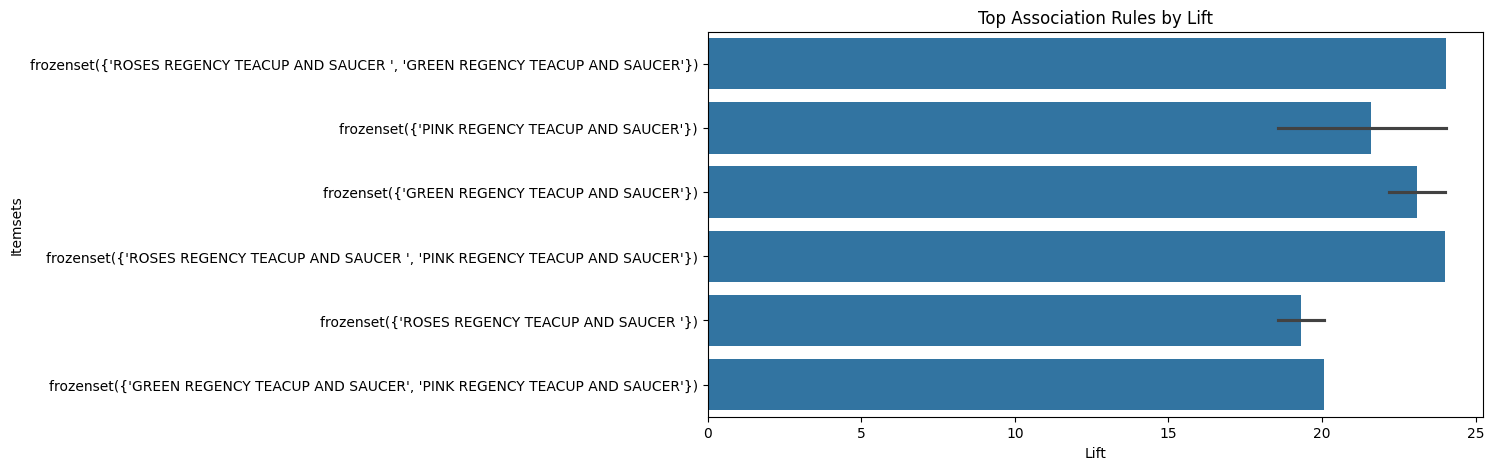

In [14]:
top_rules = rules.sort_values(
    by='lift',
    ascending=False
).head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_rules['lift'],
    y=top_rules['antecedents'].astype(str)
)

plt.title("Top Association Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Itemsets")
plt.show()

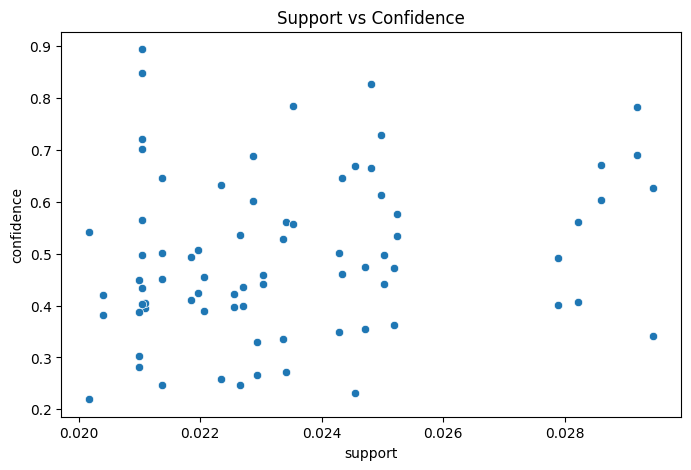

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rules,
    x='support',
    y='confidence'
)

plt.title("Support vs Confidence")
plt.show()

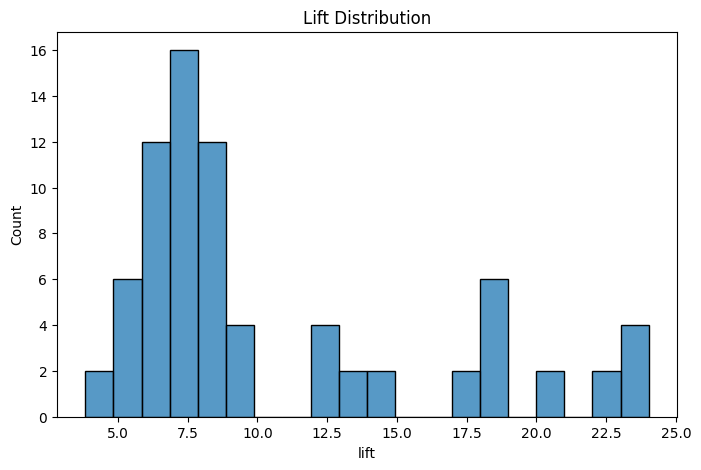

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(
    rules['lift'],
    bins=20
)

plt.title("Lift Distribution")
plt.show()

* Built an Association Rule Learning model using the Apriori algorithm
* Used the Online Retail dataset for market basket analysis
* Preprocessed and transformed transactional data into basket format
* Generated frequent itemsets from customer purchase patterns
* Created association rules using support, confidence, and lift metrics
* Visualized strong product relationships using graphs and plots
* Analyzed customer buying behavior and product associations
* Implemented a recommendation-style system similar to e-commerce platforms
